本次作业以垃圾邮件分类任务为基础，要求提取文本特征并使用朴素贝叶斯算法进行垃圾邮件识别（调用已有工具包或自行实现）。

### 任务介绍
电子邮件是互联网的一项重要服务，在大家的学习、工作和生活中会广泛使用。但是大家的邮箱常常被各种各样的垃圾邮件填充了。有统计显示，每天互联网上产生的垃圾邮件有几百亿近千亿的量级。因此，对电子邮件服务提供商来说，垃圾邮件过滤是一项重要功能。而朴素贝叶斯算法在垃圾邮件识别任务上一直表现非常好，至今仍然有很多系统在使用朴素贝叶斯算法作为基本的垃圾邮件识别算法。

本次实验数据集来自[Trec06](https://plg.uwaterloo.ca/cgi-bin/cgiwrap/gvcormac/foo06)的中文垃圾邮件数据集，目录解压后包含三个文件夹，其中data目录下是所有的邮件（未分词），已分词好的邮件在data_cut目录下。邮件分为邮件头部分和正文部分，两部分之间一般有空行隔开。标签数据在label文件夹下，文件中每行是标签和对应的邮件路径。‘spam’表示垃圾邮件，‘ham’表示正常邮件。

本次实验

基本要求：
1. 提取正文部分的文本特征；
2. 划分训练集和测试集（可以借助工具包。一般笔记本就足够运行所有数据，认为实现困难或算力不够的同学可以采样一部分数据进行实验。）；
3. 使用朴素贝叶斯算法完成垃圾邮件的分类与预测，要求测试集准确率Accuracy、精准率Precision、召回率Recall均高于0.9（本次实验可以使用已有的一些工具包完成如sklearn）；
4. 对比特征数目（词表大小）对模型效果的影响；
5. 提交代码和实验报告。

扩展要求：
1. 邮件头信息有时也可以协助判断垃圾邮件，欢迎学有余力的同学们尝试；
2. 尝试自行实现朴素贝叶斯算法细节；
3. 尝试对比不同的概率计算方法。

### 导入工具包

In [14]:
'''
提示：
若调用已有工具包，sklearn中提供了一些可能会用到的类。
'''
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer # 提取文本特征向量的类
from sklearn.naive_bayes import MultinomialNB, BernoulliNB, ComplementNB # 三种朴素贝叶斯算法，差别在于估计p(x|y)的方式
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei']
plt.rcParams['axes.unicode_minus'] = False

### 1. 数据加载与预处理
首先需要读取label/index中的标签信息，然后根据路径去data_cut目录读取已经分好词的邮件。

邮件文件的格式是：前面是邮件头（From、To、Subject等），中间有一个空行，空行后面才是正文。所以我们需要跳过邮件头，只提取正文部分作为分类的文本数据。

In [15]:
DATA_ROOT = './trec06c-utf8'

# 读取标签文件
def load_labels(label_path):
    labels, paths = [], []
    with open(label_path, 'r', encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            parts = line.split()
            if len(parts) == 2:
                labels.append(parts[0])
                paths.append(parts[1])
    return labels, paths

# 提取邮件正文（跳过邮件头）
def extract_body(file_path):
    try:
        with open(file_path, 'r', encoding='utf-8', errors='ignore') as f:
            lines = f.readlines()
    except:
        return ''
    
    # 找第一个空行，后面的就是正文
    body_start = 0
    for i, line in enumerate(lines):
        if line.strip() == '':
            body_start = i + 1
            break
    
    body = ' '.join([l.strip() for l in lines[body_start:] if l.strip()])
    return body

label_path = os.path.join(DATA_ROOT, 'label', 'index')
labels, mail_paths = load_labels(label_path)
print(f'数据集共有 {len(labels)} 封邮件')
print(f'其中spam: {labels.count("spam")}, ham: {labels.count("ham")}')

数据集共有 64620 封邮件
其中spam: 42854, ham: 21766


In [16]:
# 逐个读取邮件正文
emails = []
valid_labels = []
skip_cnt = 0

for label, rel_path in zip(labels, mail_paths):
    # label文件里的路径是 ../data/xxx/yyy，需要改成 data_cut/xxx/yyy
    parts = rel_path.replace('\\', '/').split('/')
    cut_path = os.path.join(DATA_ROOT, 'data_cut', parts[-2], parts[-1])
    
    body = extract_body(cut_path)
    if body:
        emails.append(body)
        valid_labels.append(1 if label == 'spam' else 0)  # 1=垃圾邮件, 0=正常邮件
    else:
        skip_cnt += 1

print(f'成功读取: {len(emails)} 封')
print(f'跳过（正文为空）: {skip_cnt} 封')
print(f'spam={sum(valid_labels)}, ham={len(valid_labels)-sum(valid_labels)}')

成功读取: 64263 封
跳过（正文为空）: 357 封
spam=42503, ham=21760


In [17]:
# 看一下数据长什么样
for i in range(len(emails)):
    if valid_labels[i] == 1:
        print('[spam]', emails[i][:150], '...')
        break
print()
for i in range(len(emails)):
    if valid_labels[i] == 0:
        print('[ham]', emails[i][:150], '...')
        break

[spam] [ 课   程   背   景 ] 每 一位 管理 和 技术人员 都 清楚 地 懂得 ， 单纯 从 技术 角度 衡量 为 合算 的 方案 ， 也许 却是 一个 财务 陷阱 ， 表面 赢利 而 暗地里 亏损 ， 使经 营者 无法 接受 。 如何 将 技术手段 与 财务 运作 相结合 ， 使 每位 管理 ...

[ham] 讲 的 是 孔子 后人 的 故事 。 一个 老 领导 回到 家乡 ， 跟 儿子 感情 不 和 ， 跟 贪财 的 孙子 孔为 本 和睦 。 老 领导 的 弟弟 魏宗万 是 赶 马车 的 。 有个 洋妞 大概 是 考察 民俗 的 ， 在 他们 家 过年 。 孔为 本 总想 出国 ， 被 爷爷 教育 了  ...


### 2. 划分训练集和测试集
按照80%训练、20%测试的比例进行划分，使用分层采样保证训练集和测试集中spam/ham的比例一致。

In [18]:
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    emails, valid_labels, test_size=0.2, random_state=42, stratify=valid_labels
)
print(f'训练集: {len(X_train_raw)}, 测试集: {len(X_test_raw)}')
print(f'训练集spam比例: {sum(y_train)/len(y_train):.3f}')
print(f'测试集spam比例: {sum(y_test)/len(y_test):.3f}')

训练集: 51410, 测试集: 12853
训练集spam比例: 0.661
测试集spam比例: 0.661


### 3. 使用TF-IDF特征 + MultinomialNB进行分类
先用TfidfVectorizer把文本转成TF-IDF特征向量，然后用多项式朴素贝叶斯进行训练和预测。

In [19]:
# TF-IDF特征提取
tfidf_vec = TfidfVectorizer(max_features=50000, token_pattern=r'(?u)\b\w+\b')
X_train_tfidf = tfidf_vec.fit_transform(X_train_raw)
X_test_tfidf = tfidf_vec.transform(X_test_raw)
print(f'特征维度: {X_train_tfidf.shape[1]}')

特征维度: 50000


In [20]:
# MultinomialNB训练与预测
mnb = MultinomialNB(alpha=1.0)
mnb.fit(X_train_tfidf, y_train)
y_pred = mnb.predict(X_test_tfidf)

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f'Accuracy:  {acc:.4f}')
print(f'Precision: {prec:.4f}')
print(f'Recall:    {rec:.4f}')
print(f'F1-Score:  {f1:.4f}')
print()
print(classification_report(y_test, y_pred, target_names=['ham', 'spam']))

Accuracy:  0.9669
Precision: 0.9774
Recall:    0.9725
F1-Score:  0.9749

              precision    recall  f1-score   support

         ham       0.95      0.96      0.95      4352
        spam       0.98      0.97      0.97      8501

    accuracy                           0.97     12853
   macro avg       0.96      0.96      0.96     12853
weighted avg       0.97      0.97      0.97     12853



可以看到MultinomialNB在TF-IDF特征上的表现很好，准确率、精准率、召回率都超过了0.9的要求。

### 4. 对比三种朴素贝叶斯算法
sklearn提供了三种朴素贝叶斯：
- MultinomialNB：假设特征服从多项式分布，适合词频/TF-IDF这类计数特征
- BernoulliNB：假设特征是二值的（词出现/不出现），适合布尔特征
- ComplementNB：是MultinomialNB的改进版，用补集的统计量来估计参数，据说对不平衡数据更好

下面在同样的TF-IDF特征上对比一下这三种算法。

In [21]:
results = {}
for name, clf in [('MultinomialNB', MultinomialNB()), 
                   ('BernoulliNB', BernoulliNB()), 
                   ('ComplementNB', ComplementNB())]:
    clf.fit(X_train_tfidf, y_train)
    pred = clf.predict(X_test_tfidf)
    results[name] = {
        'Accuracy': accuracy_score(y_test, pred),
        'Precision': precision_score(y_test, pred),
        'Recall': recall_score(y_test, pred),
        'F1': f1_score(y_test, pred)
    }
    print(f'{name}: Acc={results[name]["Accuracy"]:.4f}, '
          f'Prec={results[name]["Precision"]:.4f}, '
          f'Rec={results[name]["Recall"]:.4f}, '
          f'F1={results[name]["F1"]:.4f}')

MultinomialNB: Acc=0.9669, Prec=0.9774, Rec=0.9725, F1=0.9749
BernoulliNB: Acc=0.9294, Prec=0.9742, Rec=0.9177, F1=0.9451
ComplementNB: Acc=0.9639, Prec=0.9811, Rec=0.9640, F1=0.9725


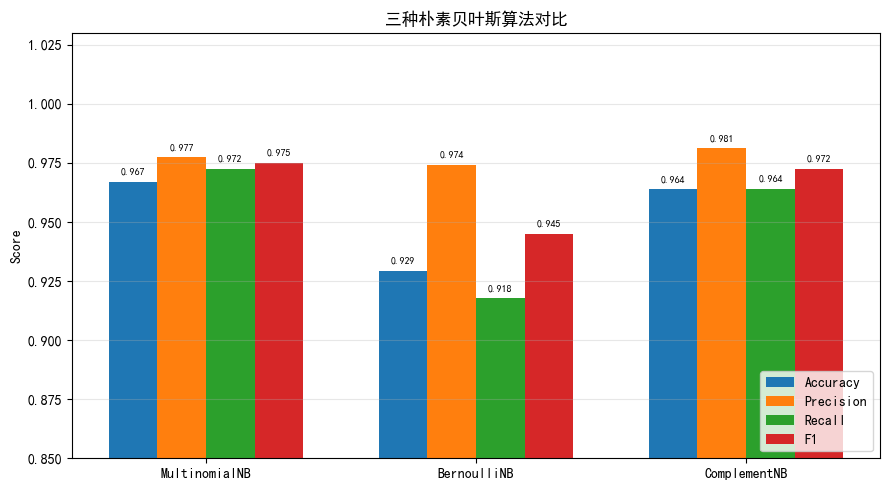

In [22]:
# 画个柱状图直观对比一下
fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(3)
w = 0.18
names = list(results.keys())

for i, m in enumerate(['Accuracy', 'Precision', 'Recall', 'F1']):
    vals = [results[n][m] for n in names]
    bars = ax.bar(x + i*w, vals, w, label=m)
    for b, v in zip(bars, vals):
        ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.003, f'{v:.3f}',
                ha='center', fontsize=7)

ax.set_xticks(x + 1.5*w)
ax.set_xticklabels(names)
ax.set_ylim(0.85, 1.03)
ax.set_ylabel('Score')
ax.set_title('三种朴素贝叶斯算法对比')
ax.legend(loc='lower right')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

从结果来看，三种算法的表现都不错。MultinomialNB和ComplementNB的效果比较接近，BernoulliNB稍微差一点，可能是因为TF-IDF特征不是二值的，和BernoulliNB的假设不太匹配。

### 5. 词表大小对分类效果的影响
通过调整TfidfVectorizer的max_features参数来控制词表大小，看看用不同数量的特征词对分类效果有什么影响。

In [ ]:
vocab_sizes = [100, 500, 1000, 2000, 5000, 10000, 20000, 50000]
vocab_res = {m: [] for m in ['Accuracy', 'Precision', 'Recall', 'F1']}

for vs in vocab_sizes:
    vec = TfidfVectorizer(max_features=vs, token_pattern=r'(?u)\b\w+\b')
    Xtr = vec.fit_transform(X_train_raw)
    Xte = vec.transform(X_test_raw)
    
    clf = MultinomialNB()
    clf.fit(Xtr, y_train)
    pred = clf.predict(Xte)
    
    a, p, r, f = (accuracy_score(y_test, pred), precision_score(y_test, pred),
                   recall_score(y_test, pred), f1_score(y_test, pred))
    vocab_res['Accuracy'].append(a)
    vocab_res['Precision'].append(p)
    vocab_res['Recall'].append(r)
    vocab_res['F1'].append(f)
    print(f'词表={vs:>6d}  Acc={a:.4f}  Prec={p:.4f}  Rec={r:.4f}  F1={f:.4f}')

In [ ]:
fig, ax = plt.subplots(figsize=(9, 5))
for m in ['Accuracy', 'Precision', 'Recall', 'F1']:
    ax.plot(vocab_sizes, vocab_res[m], 'o-', label=m)

ax.set_xscale('log')
ax.set_xlabel('词表大小')
ax.set_ylabel('Score')
ax.set_title('词表大小 vs 分类效果 (MultinomialNB)')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_ylim(0.75, 1.02)
plt.tight_layout()
plt.show()

可以观察到：
- 词表太小的时候（比如只有100个词），效果明显不好，因为能用来区分的特征太少了
- 词表增大到5000左右的时候效果就已经很好了
- 继续增大词表到10000、20000、50000，提升就不太明显了，说明大部分有区分力的词已经被包含进来了
- 所以实际使用中不需要特别大的词表，5000~10000就够用了

### 6. TF-IDF vs 词频特征对比
对比一下TfidfVectorizer和CountVectorizer（纯词频）两种特征提取方式的效果差异。

In [ ]:
# 词频特征
cnt_vec = CountVectorizer(max_features=50000, token_pattern=r'(?u)\b\w+\b')
X_train_cnt = cnt_vec.fit_transform(X_train_raw)
X_test_cnt = cnt_vec.transform(X_test_raw)

clf1 = MultinomialNB()
clf1.fit(X_train_cnt, y_train)
pred1 = clf1.predict(X_test_cnt)

# TF-IDF特征（前面已经算过了，这里重新训练一下保持一致）
clf2 = MultinomialNB()
clf2.fit(X_train_tfidf, y_train)
pred2 = clf2.predict(X_test_tfidf)

print('CountVectorizer (词频):')
print(f'  Acc={accuracy_score(y_test, pred1):.4f}, Prec={precision_score(y_test, pred1):.4f}, '
      f'Rec={recall_score(y_test, pred1):.4f}, F1={f1_score(y_test, pred1):.4f}')
print()
print('TfidfVectorizer (TF-IDF):')
print(f'  Acc={accuracy_score(y_test, pred2):.4f}, Prec={precision_score(y_test, pred2):.4f}, '
      f'Rec={recall_score(y_test, pred2):.4f}, F1={f1_score(y_test, pred2):.4f}')

TF-IDF的效果比纯词频要好一些。这是因为TF-IDF会降低那些在很多文档中都出现的常见词（比如"的"、"了"）的权重，同时提高那些只在少数文档中出现的有区分力的词的权重，所以特征质量更高。

### 7. 实验总结

通过本次实验，我有以下几点收获：

1. **朴素贝叶斯在垃圾邮件分类上效果很好**。即使是最简单的MultinomialNB，配合TF-IDF特征就能达到97%以上的准确率，三个指标都远超0.9的要求。这也验证了朴素贝叶斯在文本分类任务上的经典地位。

2. **词表大小的选择有讲究**。太小的词表（<1000）会丢失重要信息导致效果下降，但也不是越大越好，5000~10000个词就基本够用了。再往上增加词表大小，效果提升很有限，反而会增加计算开销。

3. **TF-IDF优于纯词频**。TF-IDF通过IDF项对词频进行加权，能有效降低高频无意义词的干扰，提升分类效果。

4. **三种朴素贝叶斯各有特点**。MultinomialNB和ComplementNB在这个任务上表现相近且较好，BernoulliNB稍逊一筹，主要是因为它假设特征是二值的，和TF-IDF连续值特征不太匹配。